In [21]:
import pandas as pd
import numpy as np
import scipy.stats as stat
import matplotlib.pyplot as pyplot
import seaborn as sns

from IPython.display import display_html
from pandas.io.formats import style
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer, LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
folder_path = 'csv_data/'

general_df = pd.read_csv(os.path.join(folder_path, 'general.csv'))
final_deck = pd.read_csv(os.path.join(folder_path, 'final_deck.csv'))
final_deck_ohe = pd.read_csv(os.path.join(folder_path, 'final_deck_ohe.csv'))
relic_timeline_df = pd.read_csv(os.path.join(folder_path, 'relic_timeline_df.csv'))
card_timeline_df = pd.read_csv(os.path.join(folder_path, 'card_timeline_df.csv'))

# General

In [4]:
general_df.head()

,play_id,victory,win_rate,floor_reached,danger_taken
0,8e5756d0-c239-4e9f-b77d-e098ea1c301f,False,0.0,7,27.05
1,9ad468c8-62b4-4189-acf7-939f1b339fe6,False,0.0,16,89.34
2,6c510dff-bc74-4b11-b624-c253c5ada784,False,0.0,10,28.10
3,08930040-da5c-41a4-a9c5-bb5632940228,False,0.0,13,47.62
4,8102adf0-5c1c-4230-a736-2a4b415dac0c,False,0.0,23,197.85


In [5]:
general_df['act_reached'] = np.where(
    general_df['floor_reached'].between(0,16, inclusive = 'both'), 
    'Act 1',
    np.where(
        general_df['floor_reached'].between(17,33, inclusive = 'both'), 
        'Act 2',
        np.where(
            general_df['floor_reached'].between(34,52, inclusive = 'both'), 
            'Act 3',
            'Act 4'
        )
    )
)

In [6]:
print("Dataset Shape:", general_df.shape)
print("\nData Types:\n", general_df.dtypes)
print("\nMissing Values:\n", general_df.isnull().sum())

Dataset Shape: (173174, 6)

Data Types:
 play_id              str
victory             bool
win_rate         float64
floor_reached      int64
danger_taken     float64
act_reached          str
dtype: object

Missing Values:
 play_id          0
victory          0
win_rate         0
floor_reached    0
danger_taken     0
act_reached      0
dtype: int64


In [7]:
general_df['victory'].mean()

np.float64(0.033423031170961)

<Axes: xlabel='floor_reached', ylabel='Count'>

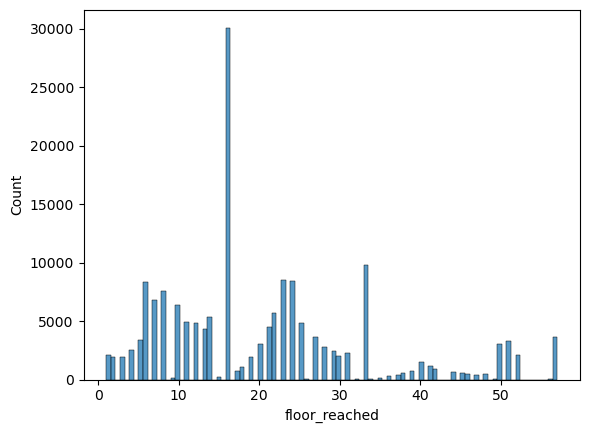

In [8]:
sns.histplot(general_df['floor_reached'])

<Axes: xlabel='danger_taken', ylabel='Count'>

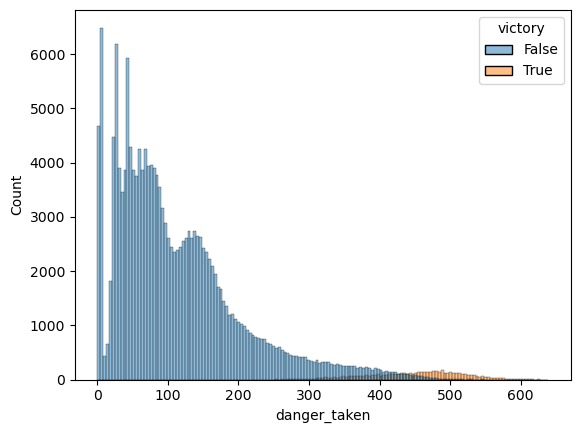

In [9]:
sns.histplot(data=general_df, x ='danger_taken', hue='victory')

<Axes: xlabel='danger_taken', ylabel='Count'>

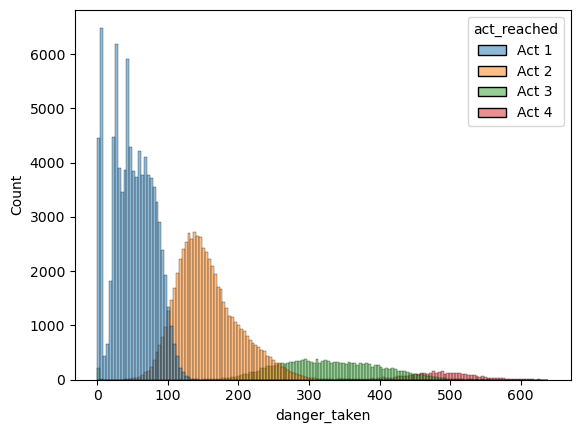

In [10]:
sns.histplot(data=general_df, x ='danger_taken', hue='act_reached')

# Processing

In [3]:
#Defend_B and Strike_B presumably stands for Defend Blue and Strike Blue, the basic cards for defect
# Some cards in this list may have different names due to them using old names for the cards in the save files
# Here is a list of cards with changed name :
# - Conserve Battery -> Charge Battery
# - Gash -> Claw
# - Lockon -> Bullseye
# - Redo -> Recursion
# - Steam Power -> Steam Barrier
# - Undo -> Equilibrium
# - Steam -> Overclock (I can't find any source of this on the web, but it is the only one left that fits)

defect_cards = {
  "Defend_B": "Basic",
  "Dualcast": "Basic",
  "Strike_B": "Basic",
  "Zap": "Basic",
  "Ball Lightning": "Common",
  "Barrage": "Common",
  "Beam Cell": "Common",
  "Conserve Battery": "Common",
  "Gash": "Common",
  "Cold Snap": "Common",
  "Compile Driver": "Common",
  "Coolheaded": "Common",
  "Go for the Eyes": "Common",
  "Hologram": "Common",
  "Leap": "Common",
  "Rebound": "Common",
  "Redo": "Common",
  "Stack": "Common",
  "Steam Power": "Common",
  "Streamline": "Common",
  "Sweeping Beam": "Common",
  "Turbo": "Common",
  "Aggregate": "Uncommon",
  "Auto Shields": "Uncommon",
  "Blizzard": "Uncommon",
  "BootSequence": "Uncommon",
  "Lockon": "Uncommon",
  "Capacitor": "Uncommon",
  "Chaos": "Uncommon",
  "Chill": "Uncommon",
  "Consume": "Uncommon",
  "Darkness": "Uncommon",
  "Defragment": "Uncommon",
  "Doom and Gloom": "Uncommon",
  "Double Energy": "Uncommon",
  "Undo": "Uncommon",
  "FTL": "Uncommon",
  "Force Field": "Uncommon",
  "Fusion": "Uncommon",
  "Genetic Algorithm": "Uncommon",
  "Glacier": "Uncommon",
  "Heatsinks": "Uncommon",
  "Hello World": "Uncommon",
  "Loop": "Uncommon",
  "Melter": "Uncommon",
  "Steam": "Uncommon",
  "Recycle": "Uncommon",
  "Reinforced Body": "Uncommon",
  "Reprogram": "Uncommon",
  "Rip and Tear": "Uncommon",
  "Scrape": "Uncommon",
  "Self Repair": "Uncommon",
  "Skim": "Uncommon",
  "Static Discharge": "Uncommon",
  "Storm": "Uncommon",
  "Sunder": "Uncommon",
  "Tempest": "Uncommon",
  "White Noise": "Uncommon",
  "All For One": "Rare",
  "Amplify": "Rare",
  "Biased Cognition": "Rare",
  "Buffer": "Rare",
  "Core Surge": "Rare",
  "Creative AI": "Rare",
  "Echo Form": "Rare",
  "Electrodynamics": "Rare",
  "Fission": "Rare",
  "Hyperbeam": "Rare",
  "Machine Learning": "Rare",
  "Meteor Strike": "Rare",
  "Multi-Cast": "Rare",
  "Rainbow": "Rare",
  "Reboot": "Rare",
  "Seek": "Rare",
  "Thunder Strike": "Rare"
}

defect_card_list = list(defect_cards.keys()) + [k+"+1" for k in defect_cards.keys()]

In [4]:
card_stats = final_deck_ohe.melt(id_vars = ['play_id'], var_name = 'card', value_name = 'count')\
    .query('count > 0')\
    .merge(general_df[['play_id', 'victory', 'danger_taken']], on = 'play_id')\
    .groupby('card').agg({'play_id':'nunique', 'victory': 'mean', 'danger_taken': 'mean'})\
    .rename(columns = {'play_id': 'total_runs', 'victory': 'win_rate', 'danger_taken': 'avg_danger_taken'})

In [5]:
card_stats['rarity'] = card_stats.index.map(lambda x: defect_cards.get(x.replace('+1', '')))
card_stats['upgraded'] = card_stats.index.map(lambda x: '+1' in x)

### Make final_relic_df

In [44]:
relic_timeline_grouped = relic_timeline_df.groupby('play_id')['relic_obtained'].agg(
    lambda x : tuple(x)
)
final_relic_df = pd.DataFrame(
    columns = ['play_id', 'relics_tuple']
)
final_relic_df['relics_tuple'] = relic_timeline_grouped.values
final_relic_df['play_id'] = relic_timeline_grouped.index
final_relic_df.set_index('play_id', inplace = True)

In [45]:
mlb = MultiLabelBinarizer(sparse_output=True)

final_relic_df =final_relic_df.join(
    pd.DataFrame.sparse.from_spmatrix(
        mlb.fit_transform(final_relic_df.pop('relics_tuple')),
        index = final_relic_df.index,
        columns = mlb.classes_
    )
)

# Top cards by danger taken

## Rare

In [6]:
temp1 = card_stats.query('upgraded == False and rarity == "Rare"')\
    [['total_runs', 'win_rate', 'avg_danger_taken']]\
    .sort_values('avg_danger_taken', ascending = False)

temp1

,total_runs,win_rate,avg_danger_taken
card,,,
Electrodynamics,20121,0.082203,215.275242
Echo Form,19284,0.093756,205.576760
Core Surge,17586,0.087172,201.702849
Biased Cognition,11383,0.076605,200.548638
Meteor Strike,4395,0.108987,195.713367
Creative AI,10082,0.079449,190.629981
Reboot,7811,0.069645,190.474693
Rainbow,7109,0.061893,189.302677
All For One,8522,0.061136,188.027112


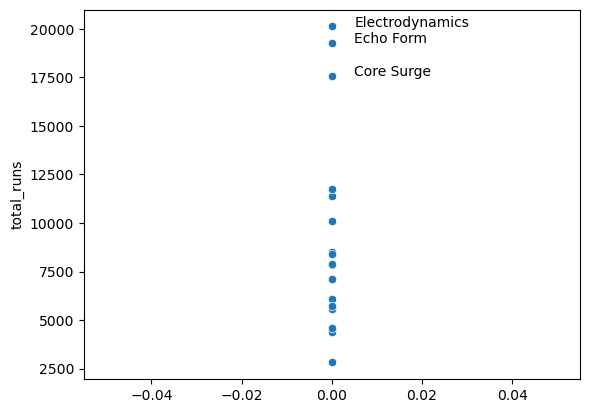

In [7]:
p1 = sns.scatterplot(data = temp1, y = 'total_runs', x = 0)

for card in temp1.sort_values('total_runs', ascending = False).index[:3]:
    p1.text(x = 0.005, y = temp1.loc[card, 'total_runs'], s = card, horizontalalignment='left')

Most of the card rankings align roughly with my evaluation of them with some exceptions, namely Seek and Buffer, because I expected them to be higher on the ranking.

There are 3 rare cards that see significantly more usage compared to other cards : Electrodynamics, Echo Form, and Core Surge.

Meteor Strike having the 2nd lowest pick rate out of all rare cards, but also the highest winrate is most likely due to the fact that Meteor Strike requires certain cards/relics for it to be playable. But when it does become playable, it is a very powerful card.

Hyperbeam as expected, is the card with the lowest, lowest winrate, and lowest avg_danger_taken. If there is any card from this list that needs some touch up, it would be Hyperbeam.

A close 2nd to last is Fission, but I suspect the upgrade will boost its stats by a good amount.

In [8]:
temp2 = card_stats.query('upgraded == True and rarity == "Rare"')\
    [['total_runs', 'win_rate', 'avg_danger_taken']]\
    .sort_values('avg_danger_taken', ascending = False)
temp2

,total_runs,win_rate,avg_danger_taken
card,,,
Seek+1,5850,0.275385,294.168918
Meteor Strike+1,1235,0.309312,290.337652
Amplify+1,2044,0.252446,289.994922
Reboot+1,2208,0.260417,286.841916
Biased Cognition+1,7601,0.242731,280.032669
Electrodynamics+1,5640,0.160638,262.208615
Buffer+1,7820,0.177110,256.253978
Echo Form+1,5438,0.187753,252.846280
Core Surge+1,2506,0.178771,252.656073


In [9]:
tmp1 = dict(zip(temp1.index, range(len(temp1.index))))
tmp2 = dict(zip([i.replace('+1', '') for i in temp2.index], range(len(temp2.index))))

{card: tmp1[card] - tmp2[card] for card in temp1.index}

{'Electrodynamics': -5,
 'Echo Form': -6,
 'Core Surge': -6,
 'Biased Cognition': -1,
 'Meteor Strike': 3,
 'Creative AI': -10,
 'Reboot': 3,
 'Rainbow': -7,
 'All For One': -4,
 'Seek': 9,
 'Machine Learning': 0,
 'Amplify': 9,
 'Multi-Cast': -1,
 'Buffer': 7,
 'Thunder Strike': 5,
 'Fission': 4,
 'Hyperbeam': 0}

For upgraded rares, Seek takes the number one spot moving up by 9 ranks, which is reasonable, as it is just a pot of greed but better. Amplify also moved up 9 ranks by upgrading.

Fission moved up by 4 spots, putting it on the 12th place, which is not what I expected.

The top 5 is has 20%+ winrates, which is significantly higher than the rest of the upgraded cards

Hyperbeam is still at last place by a large margin



## Uncommon

In [10]:
temp1 = card_stats.query('upgraded == False and rarity == "Uncommon"')\
    [['total_runs', 'win_rate', 'avg_danger_taken']]\
    .sort_values('avg_danger_taken', ascending = False)

temp1

,total_runs,win_rate,avg_danger_taken
card,,,
Force Field,6241,0.095978,198.356012
Glacier,30769,0.081478,186.409846
Skim,7391,0.085645,180.947995
Undo,13988,0.066986,180.290577
Chill,19396,0.067746,178.235728
Aggregate,1749,0.049743,172.378674
Reinforced Body,12105,0.057414,170.343396
Heatsinks,6896,0.079031,170.160770
BootSequence,15881,0.047730,168.917047


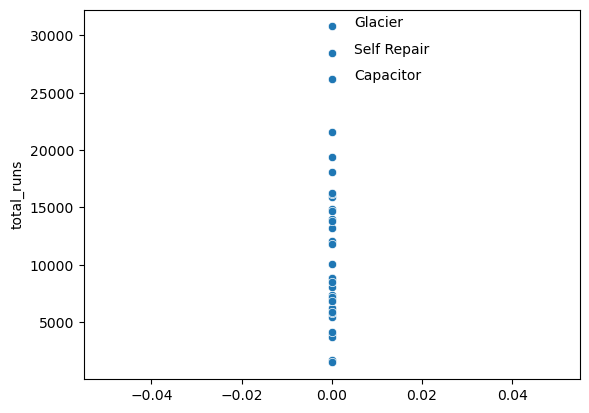

In [11]:
p1 = sns.scatterplot(data = temp1, y = 'total_runs', x = 0)

for card in temp1.sort_values('total_runs', ascending = False).index[:3]:
    p1.text(x = 0.005, y = temp1.loc[card, 'total_runs'], s = card, horizontalalignment='left')

The top 5 uncommon cards are all defensive cards except Skim.
Similar to rare cards, there are 3 cards that have significantly higher pick rate than the rest of the cards, however only 1 of these cards (Glacier) is in the top 5 in terms of average danger taken.

Reprogram is similar to Hyperbeam, in that it has low pick rates and terrible win rates and danger taken

In [12]:
temp1 = card_stats.query('upgraded == True and rarity == "Uncommon"')\
    [['total_runs', 'win_rate', 'avg_danger_taken']]\
    .sort_values('avg_danger_taken', ascending = False)

temp1

,total_runs,win_rate,avg_danger_taken
card,,,
Skim+1,3397,0.301442,295.816623
Heatsinks+1,3573,0.312622,291.996306
Force Field+1,2275,0.223297,289.167020
BootSequence+1,2549,0.169086,258.022797
Undo+1,3501,0.163668,251.988512
Chill+1,5154,0.180636,251.537643
Double Energy+1,3836,0.183003,248.608741
Glacier+1,7974,0.186857,247.648706
Reinforced Body+1,5195,0.160346,242.898385


When upgraded, card draws (Skim and Heatsinks) become more relevant.

## Common

In [13]:
temp1 = card_stats.query('upgraded == False and rarity == "Common"')\
    [['total_runs', 'win_rate', 'avg_danger_taken']]\
    .sort_values('avg_danger_taken', ascending = False)

temp1

,total_runs,win_rate,avg_danger_taken
card,,,
Steam Power,2932,0.069236,176.641102
Compile Driver,19538,0.065104,171.976530
Stack,7493,0.046443,170.200223
Hologram,19583,0.063065,166.775539
Ball Lightning,53718,0.040731,158.436813
Cold Snap,48763,0.043824,157.945299
Turbo,13897,0.045118,157.136390
Barrage,12486,0.043168,157.110414
Coolheaded,42312,0.046110,155.499999


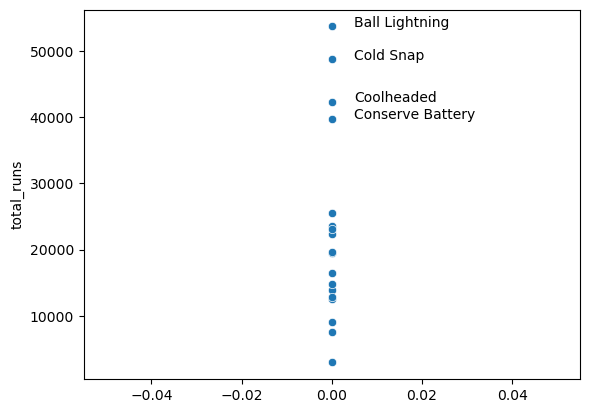

In [14]:
p1 = sns.scatterplot(data = temp1, y = 'total_runs', x = 0)

for card in temp1.sort_values('total_runs', ascending = False).index[:4]:
    p1.text(x = 0.005, y = temp1.loc[card, 'total_runs'], s = card, horizontalalignment='left')

This time with common cards, there are 4 cards with higher pick rates than the rest, however only Ball Lightning and Cold Snap are near the top. 

Interestingly, Steam Barrier(Steam Power is an old name) has the highest win rate and avg_damage_taken while having the lowest pick rates out of all commons.


In [15]:
temp1 = card_stats.query('upgraded == True and rarity == "Common"')\
    [['total_runs', 'win_rate', 'avg_danger_taken']]\
    .sort_values('avg_danger_taken', ascending = False)

temp1

,total_runs,win_rate,avg_danger_taken
card,,,
Steam Power+1,1225,0.215510,275.395486
Turbo+1,6006,0.212288,257.259387
Stack+1,3205,0.136349,253.500231
Compile Driver+1,4502,0.144825,241.190291
Hologram+1,12434,0.150635,235.412168
Coolheaded+1,19467,0.170648,233.313260
Leap+1,5774,0.104953,227.714118
Conserve Battery+1,9119,0.109332,223.578490
Cold Snap+1,8353,0.100922,218.147196


# Pre-modelling Processing

In [40]:
final_deck_ohe.set_index('play_id', inplace = True)

In [ ]:
final_deck_ohe = final_deck_ohe.join(final_relic_df, how = 'left', on="play_id").fillna(0)

,Defend_B,Dualcast,Strike_B,Zap,Ball Lightning,Barrage,Beam Cell,Conserve Battery,Gash,Cold Snap,...,Toy Ornithopter,TungstenRod,Turnip,Unceasing Top,Vajra,War Paint,Whetstone,White Beast Statue,WingedGreaves,hubris:PeanutButter
play_id,,,,,,,,,,,,,,,,,,,,,
494a8971-45ba-4136-a761-8c2c5731cf1b,0,1,0,1,1,0,0,0,0,2,...,0,0,0,0,1.0,0,0,0,1.0,0
10189f6b-63ad-4634-9ff5-cea03e3b84ba,4,0,3,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
8b743589-a9e9-4309-ab65-acfe58735163,3,1,1,0,1,1,0,1,0,0,...,0,0,0,0,1.0,0,0,0,0,0
51b42d50-72bb-4517-b00b-1a87aa51d0c1,4,1,3,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
d71543f5-f845-4418-b202-a11709981274,4,1,2,1,1,0,0,0,2,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dbd5d76c-a2ec-4ff9-b4fd-955aec864cf4,4,1,4,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2c1027fe-3a70-4bb5-85ca-f63c446511fb,3,1,4,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7d9e0db0-533e-428d-a3a5-94917474e66c,4,1,4,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:

train_df, temp_df = train_test_split(final_deck_ohe, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

del temp_df

X_train_raw = train_df[defect_card_list]
X_val_raw = val_df[defect_card_list]
X_test_raw = test_df[defect_card_list]


In [49]:
class DeckState(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        return self.data[idx]

In [50]:
train_dataset = DeckState(X_train_raw.values)
val_dataset = DeckState(X_val_raw.values)
test_dataset = DeckState(X_test_raw.values)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# Modelling

In [51]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Auto Encoder

### Model Definition

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim

class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=16):
        super(Autoencoder, self).__init__()
        
        # Encoder: compresses input into lower-dimensional latent space
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, encoding_dim),
            nn.ReLU()
        )
        
        # Decoder: reconstructs original input from the latent space representation
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            # Sigmoid is suitable for binary indicators or scaled features in [0, 1]
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

def train_autoencoder(model, train_loader, val_loader, epochs=50, lr=1e-3, device='cpu'):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': []}
    model.to(device)
    
    for epoch in range(1, epochs + 1):
        # Training phase
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            # Handle datasets that yield a single tensor (like DeckState) or (x, y) tuples
            if isinstance(batch, (list, tuple)):
                batch_x = batch[0]
            else:
                batch_x = batch
                
            batch_x = batch_x.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_x)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * batch_x.size(0)
            
        train_loss /= len(train_loader.dataset)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                if isinstance(batch, (list, tuple)):
                    batch_x = batch[0]
                else:
                    batch_x = batch
                    
                batch_x = batch_x.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_x)
                val_loss += loss.item() * batch_x.size(0)
                
        val_loss /= len(val_loader.dataset)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch [{epoch}/{epochs}] - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")
            
    return history

### Model Training

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=150, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=150, bias=True)
    (5): Sigmoid()
  )
)
Epoch [1/50] - Train Loss: 0.132068 - Val Loss: 0.126148
Epoch [10/50] - Train Loss: 0.111591 - Val Loss: 0.111241
Epoch [20/50] - Train Loss: 0.109689 - Val Loss: 0.110772
Epoch [30/50] - Train Loss: 0.109084 - Val Loss: 0.109034
Epoch [40/50] - Train Loss: 0.108964 - Val Loss: 0.110013
Epoch [50/50] - Train Loss: 0.108800 - Val Loss: 0.111364


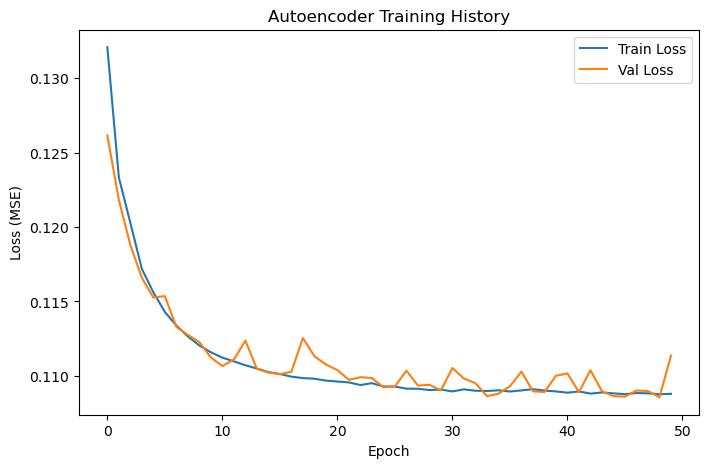

In [53]:
# Instantiate model, set device, run training, and plot history
import matplotlib.pyplot as plt

# Get the input dimension from the features of our dataset
input_dim = X_train_raw.shape[1] if 'X_train_raw' in globals() else 150
encoding_dim = 16  # Dimension of the latent representation

# Initialize model
ae_model = Autoencoder(input_dim=input_dim, encoding_dim=encoding_dim)
print(ae_model)

# Train the model
history = train_autoencoder(
    model=ae_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    lr=0.001,
    device=device
)

# Plot the training history
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Autoencoder Training History')
plt.legend()
plt.show()

### Model Saving

In [14]:
torch.save(ae_model.state_dict(), 'autoencoder_model.pth')

### Read Model from Save file

In [12]:
autoencoder_model = Autoencoder(input_dim=input_dim, encoding_dim=encoding_dim)
autoencoder_model.load_state_dict(torch.load('autoencoder_model.pth', map_location=device))

<All keys matched successfully>

### Model Eval

In [13]:
loss_fn = nn.MSELoss()
losses  = []
for batch in test_loader: 
    with torch.no_grad():

        output = autoencoder_model(batch)
        loss = loss_fn(output, batch)
        losses.append(loss.item())
print(f"Average Test Loss: {np.mean(losses):.6f}")


Average Test Loss: 0.112017


### Processing

In [14]:
encoder_model = autoencoder_model.encoder

In [15]:
auto_encoded_final_deck = pd.DataFrame(
    data=encoder_model(
        torch.tensor(
            final_deck_ohe[defect_card_list].values
            , dtype=torch.float32
        )
    ).detach().numpy()
)

In [16]:
auto_encoded_final_deck.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,8.133879,3.449100,0.0,17.610670,19.660866,19.820347,0.0,5.739017,8.441708,5.402435,17.115606,16.568169,11.343129,9.893156,0.0,10.546526
1,5.429400,8.952183,0.0,7.601936,9.960023,0.000000,0.0,7.016763,10.875842,0.000000,2.852033,6.442244,6.374982,6.451380,0.0,1.440732
2,7.458899,1.966916,0.0,4.560582,14.431022,1.837089,0.0,8.335002,8.826130,0.000000,6.141676,5.097218,8.501724,6.186027,0.0,4.209823
3,7.479855,6.235839,0.0,3.290658,12.784562,3.978655,0.0,2.994566,8.462414,1.378925,3.162597,7.656816,11.387285,3.903657,0.0,3.954313
4,6.191654,6.365120,0.0,1.094278,4.655958,0.675479,0.0,1.457965,8.189786,1.100408,3.938100,9.468468,3.754269,4.101604,0.0,10.463126


In [17]:
auto_encoded_final_deck['play_id'] = final_deck_ohe['play_id']

In [21]:
final_deck["floor_reached"].describe()

count    203817.000000
mean         17.388643
std          14.078597
min           0.000000
25%           7.000000
50%          16.000000
75%          24.000000
max          57.000000
Name: floor_reached, dtype: float64

In [25]:
auto_encoded_df = pd.merge(
    auto_encoded_final_deck,
    final_deck[['play_id', 'victory', 'danger_taken', 'master_deck']],
    on='play_id'
)
auto_encoded_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,play_id,victory,danger_taken,master_deck
0,8.133879,3.449100,0.0,17.610670,19.660866,19.820347,0.0,5.739017,8.441708,5.402435,17.115606,16.568169,11.343129,9.893156,0.0,10.546526,494a8971-45ba-4136-a761-8c2c5731cf1b,False,233.53,"[AscendersBane, Strike_B+1, Strike_B+1, Defend..."
1,5.429400,8.952183,0.0,7.601936,9.960023,0.000000,0.0,7.016763,10.875842,0.000000,2.852033,6.442244,6.374982,6.451380,0.0,1.440732,10189f6b-63ad-4634-9ff5-cea03e3b84ba,False,62.52,"[AscendersBane, Strike_B, Strike_B, Strike_B, ..."
2,7.458899,1.966916,0.0,4.560582,14.431022,1.837089,0.0,8.335002,8.826130,0.000000,6.141676,5.097218,8.501724,6.186027,0.0,4.209823,8b743589-a9e9-4309-ab65-acfe58735163,False,232.30,"[AscendersBane, Strike_B, Defend_B, Defend_B, ..."
3,7.479855,6.235839,0.0,3.290658,12.784562,3.978655,0.0,2.994566,8.462414,1.378925,3.162597,7.656816,11.387285,3.903657,0.0,3.954313,51b42d50-72bb-4517-b00b-1a87aa51d0c1,False,96.27,"[AscendersBane, Strike_B, Strike_B, Strike_B, ..."
4,6.191654,6.365120,0.0,1.094278,4.655958,0.675479,0.0,1.457965,8.189786,1.100408,3.938100,9.468468,3.754269,4.101604,0.0,10.463126,d71543f5-f845-4418-b202-a11709981274,False,207.24,"[AscendersBane, Strike_B, Strike_B, Defend_B, ..."
